In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import datasets
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset, IterableDataset, get_worker_info
import torch.optim as optim
import matplotlib.pyplot as plt
from tqdm import tqdm

/home/rianbutala/projects/wm1/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dataset = datasets.load_dataset("mvp-lab/LLaVA-OneVision-1.5-Mid-Training-85M", streaming=True)

In [3]:
# type(next(iter(dataset['train']['image'])))
# PIL.PngImagePlugin.PngImageFile

In [4]:
transform = transforms.Compose([
  transforms.Resize((256,256)),
  transforms.PILToTensor(),
  transforms.ConvertImageDtype(torch.float32)
])

# class ImageDataset(Dataset):
#   def __init__(self,dataset, transform=None):
#     super().__init__()
#     self.transform=transform
#     self.dataset = dataset
#     self.dataset_iter = iter(self.dataset['train']['image'])

#   def __len__(self):
#     return int(1e10)

#   def __getitem__(self,idx):
#     try:
#       next_img = next(self.dataset_iter)
#     except StopIteration:
#       self.dataset_iter = iter(self.dataset['train']['image'])
#       next_img = next(self.dataset_iter)

#     return self.transform(next_img)
class ImageDataset(IterableDataset):
  def __init__(self,dataset, transform=None):
    super().__init__()
    self.dataset = dataset
    self.transform = transform
    
  def __iter__(self):
    stream = self.dataset
    info=get_worker_info()
    if info is not None:
      stream = stream.shard(num_shards=info.num_workers, index=info.id)
    for item in stream:
      yield self.transform(item['image'].convert("RGB"))
  

In [5]:
ds=ImageDataset(dataset['train'], transform)
loader=DataLoader(ds,batch_size=1,num_workers=4)

In [6]:
# next(iter(loader)).shape
# torch.Size([1, 3, 256, 256])

<h3> btw </h3>
<p> scaling_factor is the patch size, and seq_len is the number of patches

In [7]:
def patchify(tensor, seq_len):
  # takes tensor of b,c,h,w
  # returns b,s,c tensor
  B, C, H, W = tensor.shape
  assert H==W # square patch
  assert int(seq_len**0.5) ** 2 == seq_len
  assert (H*W)%seq_len ==0

  scaling_factor = int(H/(seq_len**0.5))
  tensor = tensor.reshape(B,C,H//scaling_factor, scaling_factor, W//scaling_factor,scaling_factor)
  tensor = tensor.permute(0,2,4,1,3,5)
  tensor = tensor.reshape(B, H//scaling_factor* W//scaling_factor, C*scaling_factor*scaling_factor)
  return tensor

def unpatchify(tensor,height):
  # assume h,w is the same
  width=height
  B, S, C = tensor.shape
  scaling_factor = int(height/(S**0.5))
  # tensor shape as it stands: b, h//scf * w//scf, c*scf*scf
  image_c = C//scaling_factor//scaling_factor
  tensor = tensor.reshape(B,height//scaling_factor,width//scaling_factor,image_c,scaling_factor,scaling_factor)
  tensor = tensor.permute(0,3,1,4,2,5)
  # b,c,h//scf,scf,w//scf,scf
  tensor = tensor.reshape(B,image_c,height,width)
  return tensor

example = torch.rand(1,3,256,256)
print(f"patch: {patchify(example, seq_len=256).shape}")
print(f"unpatch: {unpatchify(patchify(example,seq_len=256),height=256).shape}")
  

patch: torch.Size([1, 256, 768])
unpatch: torch.Size([1, 3, 256, 256])


In [8]:
class Block(nn.Module):
  def __init__(self,nhead=4,seq=256,emb=768):
    super().__init__()
    self.seq=seq
    self.emb=emb
    self.nhead=nhead
    assert emb%nhead==0

    self.ln1 = nn.LayerNorm(emb)
    self.qkv_proj = nn.Linear(emb,emb*3)
    self.o_proj = nn.Linear(emb,emb)

    self.ln2 = nn.LayerNorm(emb)
    self.mlp = nn.Sequential(
      nn.Linear(emb,emb*4),
      nn.GELU(),
      nn.Linear(emb*4,emb)
    )
    
  def forward(self,x):
    # x shape b,s,c
    b,s,c=x.shape
    # x = self.ln1(x)
    qkv=self.qkv_proj(self.ln1(x))
    q,k,v = qkv.chunk(3,dim=-1)
    q = q.view(b,s,self.nhead,c//self.nhead).transpose(2,1)
    k = k.view(b,s,self.nhead,c//self.nhead).transpose(2,1)
    v = v.view(b,s,self.nhead,c//self.nhead).transpose(2,1)

    attn_out = F.scaled_dot_product_attention(q,k,v)
    attn_out = attn_out.transpose(2,1).contiguous().reshape(b,s,c)
    attn_out = self.o_proj(attn_out)
    # x += attn_out
    x = x+attn_out

    # x += self.mlp(self.ln2(x))
    x = x+self.mlp(self.ln2(x))

    return x

class Encoder(nn.Module):
  # todo add positional embeddings and maybe patch embeddings idk
  # todo add layer norm
  def __init__(self,nlayer=4,nhead=4,seq=256,emb=768):
    super().__init__()
    self.blocks=nn.ModuleList([Block(nhead,seq,emb) for _ in range(nlayer)])

  def forward(self,x):
    # pos_emb = embed(context_indices)
    # x+=pos_emb
    for block in self.blocks:
      x = block(x)

    return x

class Predictor(nn.Module):
  def __init__(self,nlayer=4,nhead=4,seq=256,emb=768,dim=384):
    super().__init__()
    self.blocks=nn.ModuleList([Block(nhead,seq,dim) for _ in range(nlayer)]) #normally head,seq,emb but we downcast
    # self.register_buffer("emb_idx", torch.arange(0,seq))
    self.down=nn.Linear(emb,dim)
    self.up=nn.Linear(dim,emb)
    
  def forward(self,x):
    # print("predictor forward")
    x = self.down(x)
    # print("down")
    # pos_emb = embed(self.emb_idx)
    # x+=pos_emb
    # print("start loop")
    for block in self.blocks:
      # print("loop")
      x = block(x)

    # print("loop done")
    x = self.up(x)
    # print("up")
    return x

# quick warning for anyone reading this with their own human eyes: yes i know all the variables have the wrong names no i will not change it
class InformedPredictor(nn.Module):
  def __init__(self,seq=256,emb=768,masked_tokens=10):
    super().__init__()
    self.encoder = Encoder(seq=seq,emb=emb)
    self.target_encoder = Encoder(seq=seq,emb=emb)
    self.predictor = Predictor(seq=seq,emb=emb)
    assert masked_tokens <= seq
    self.seq=seq
    self.emb=emb
    self.masked_tokens=masked_tokens
    self.embed = nn.Embedding(seq,emb)
    self.register_buffer("pos_idx", torch.arange(0,seq))
    # self.register_buffer("mask_token_embedding", torch.ones(self.masked_tokens,emb))
    self.mask_token_embedding = nn.Parameter(torch.randn(1,emb))

    self.target_encoder.load_state_dict(self.encoder.state_dict())
    for p in self.target_encoder.parameters():
      p.requires_grad = False

  def forward(self,x):
    x = patchify(x,self.seq)
    b,s,c = x.shape
    # x += self.embed(self.pos_idx)
    x = x+self.embed(self.pos_idx)
    x_orig = x.clone()
    # b,256,768 for ex.

    # inv_masked_token_idx = torch.randint(0,self.seq,torch.Size([self.seq-self.masked_tokens]))
    # inv_masked_token_idx = torch.randperm(self.seq-self.masked_tokens)
    all_perms = torch.randperm(self.seq, device=x.device)
    inv_masked_token_idx = all_perms[:self.seq-self.masked_tokens]
    filtered_x =x [:,inv_masked_token_idx,:]

    encoded_x = self.encoder(filtered_x) #b,seq-mask,c
    mask = torch.isin(self.pos_idx,inv_masked_token_idx) # which elements of inv masked token idx in pos idx
    mask_token_idx = self.pos_idx[~mask]
    mask_tokens = self.embed(mask_token_idx).unsqueeze(0).expand(b,-1,-1)
    mask_tokens = mask_tokens+self.mask_token_embedding.unsqueeze(0).expand(b,self.masked_tokens,-1)

    # print(f"sanity: {encoded_x.shape, mask_tokens.shape}")
    predicted_x = self.predictor(torch.cat([encoded_x,mask_tokens],dim=1)) # b,s,c
    with torch.no_grad():
      encoded_x = self.target_encoder(x_orig)

    mask_pred = predicted_x[:,self.seq-self.masked_tokens:,:]
    target_pred = encoded_x[:,mask_token_idx,:]
    return mask_pred, target_pred


In [9]:
with torch.no_grad():
  jepa=InformedPredictor()
  out, filtered_out = jepa(example)
  print(out.shape,filtered_out.shape)

  enc=Encoder()
  print(enc(patchify(example,256)).shape)
  # enc(filtered_out).shape

torch.Size([1, 10, 768]) torch.Size([1, 10, 768])
torch.Size([1, 256, 768])


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# torch.autograd.set_detect_anomaly(True, check_nan=False)
model = InformedPredictor().to(device)
loss_fn = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4)

steps = 1000
ema_beta = 0.999
dl_iter = iter(loader)
pbar = tqdm(total=steps)
# for step in tqdm(range(steps)):
for step in range(steps):
  try:
    data = next(dl_iter).to(device)
    # data = torch.randn((1,3,256,256))
  except StopIteration:
    dl_iter = iter(loader)
    data = next(dl_iter).to(device)

  mask_pred, target_pred = model(data)
  loss = loss_fn(mask_pred, target_pred)
  # print(f"loss: {loss.item()}")
  loss.backward()
  optimizer.step()
  optimizer.zero_grad()
  pbar.update(1)
  pbar.set_postfix(loss=loss.item())


  for param, reference in zip(model.target_encoder.parameters(), model.encoder.parameters()):
    param.data.mul_(ema_beta).add_(reference.data, alpha=1-ema_beta)

100%|██████████| 1000/1000 [01:16<00:00, 79.67it/s, loss=0.418]

100%|██████████| 1000/1000 [01:28<00:00, 79.67it/s, loss=0.418]

In [19]:
print(f"ctx encoder params {sum([p.numel() for p in model.encoder.parameters()])/1_000_000:.2f}m params")
print(f"target encoder params {sum([p.numel() for p in model.target_encoder.parameters()])/1_000_000:.2f}m params")
print(f"predictor params {sum([p.numel() for p in model.predictor.parameters()])/1_000_000:.2f}m params")
print(f"embedding params {sum([p.numel() for p in model.embed.parameters()])/1_000_000:.2f}m params")

ctx encoder params 28.35m params
target encoder params 28.35m params
predictor params 7.69m params
embedding params 0.20m params


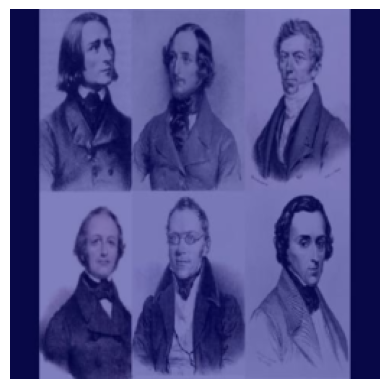

In [35]:
@torch.no_grad()
def get_attn_maps(x):
  maps = []
  for block in model.encoder.blocks:
    b,s,c =x.shape
    h = block.nhead
    q,k,v = block.qkv_proj(block.ln1(x)).chunk(3,dim=-1)
    q = q.view(b,s,h,c//h).transpose(1,2)
    k = k.view(b,s,h,c//h).transpose(1,2)
    v = v.view(b,s,h,c//h).transpose(1,2)# b,h,s,c//h
    weights = (q@k.transpose(-2,-1)) / (c//h)**0.5 # b,h,s,s
    weights = weights.softmax(dim=1)
    maps.append(weights[0].cpu().detach())
    out = (weights@v).transpose(1,2).reshape(b,s,c)
    x = x+block.o_proj(out)
    x = x+block.mlp(block.ln2(x))
  return maps

    
# plt.imshow(data.detach().cpu().squeeze(0).permute(1,2,0).numpy())
model.eval()
img = data
x = patchify(img,seq_len=model.seq) + model.embed(model.pos_idx)
maps = get_attn_maps(x)

# from here on out is between claude opus and god alone. i could not possibly tell you what this means

g = int(model.seq**0.5) # 16
heat = maps[-1].mean(0).mean(0).reshape(g,g)
heat = F.interpolate(heat[None,None], size=(256,256), mode="bilinear")[0,0]

plt.imshow(img[0].cpu().permute(1,2,0).numpy())
plt.imshow(heat.cpu().numpy(),cmap='jet',alpha=0.5)
plt.axis("off"); plt.show()